# Backtrader Indicator Verification

In [65]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
from pandas import read_csv
from datetime import datetime

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.plots import curve, comparison
from lib.data import stats, ou
from lib.utils import extract_date_range
from lib import trading

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [37]:
def zscore_plot(zscore, zdate, window):
    title = f'USD.CAD Exchange Rate Z-Score: $t_{{1/2}} = {window:.0f}$ days'
    curve(zscore, zdate, title=title, xlabel=f"Day", ylabel="Z-Score", lw=1)

def zscore_indicator_plot(zscore, zdate, window):
    title = f'USD.CAD Exchange Rate Z-Score Indicator: $t_{{1/2}} = {window:.0f}$ days'
    curve(zscore, zdate, title=title, xlabel=f"Day", ylabel="Z-Score", lw=1)

def zscore_trading_plot(zscore, zdate, window):
    title = f'USD.CAD Exchange Rate Z-Score from Trading: $t_{{1/2}} = {window:.0f}$ days'
    curve(zscore, zdate, title=title, xlabel=f"Day", ylabel="Z-Score", lw=1)

def exchange_rate_plot(data, date):
    title = 'USD.CAD Exchange Rate'
    mean = numpy.full(len(data), numpy.mean(data))
    comparison([data, mean], date, title=title, xlabel="Date", ylabel="USD.CAD", labels=['USD.CAD', 'Mean'], lw=1)
    
def compute_mean_reversion_halflife(data):
    mean = numpy.full(len(data), numpy.mean(data))
    xt = data - mean
    result, result_model = ou.compute_mean_half_life_estimate(xt)
    return int(result_model.param_transforms[0].param.est), result

In [39]:
file_path = os.path.abspath('../../../data/algorithmic_trading/CAD=X.csv')
usd_cad_data = read_csv(file_path, index_col=0, parse_dates=True).sort_values(by='Date').dropna()
usd_cad_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2003-09-17,1.3667,1.3704,1.3636,1.3667,1.3667,0.0
2003-09-18,1.3660,1.3685,1.3597,1.3615,1.3615,0.0
2003-09-19,1.3620,1.3630,1.3457,1.3472,1.3472,0.0
2003-09-22,1.3413,1.3553,1.3365,1.3542,1.3542,0.0
2003-09-23,1.3549,1.3577,1.3458,1.3551,1.3551,0.0


In [22]:
date, usd_cad_close = extract_date_range(usd_cad_data.index.to_numpy(), usd_cad_data['Close'].to_numpy(), '2007-07-22', '2012-03-28')

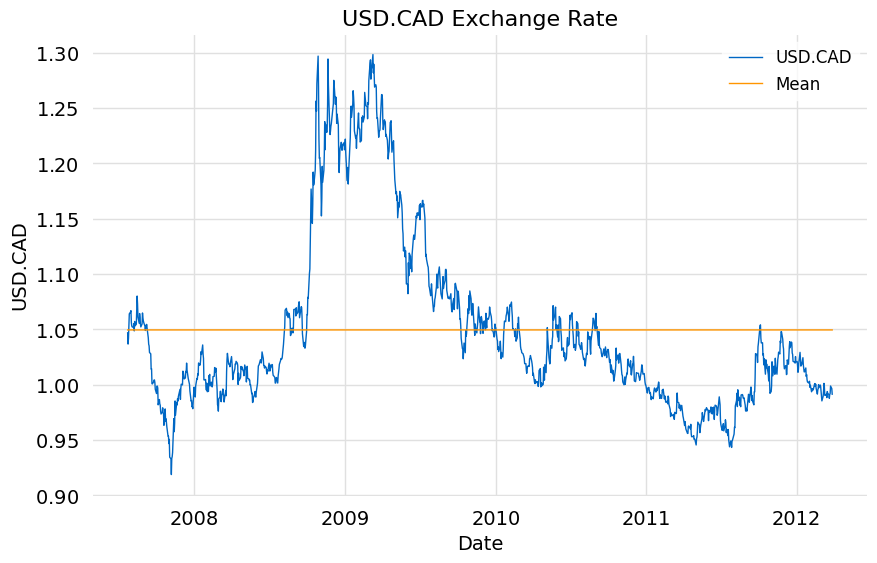

In [40]:
exchange_rate_plot(usd_cad_close, date)

## Mean Conversions Half-Life

The normalized deviation of the price, Z-Score, is defined by

$
\begin{align}
Z = \frac{y - \text{moving\_avg}(y, \text{halflife})}{\text{moving\_std}(y, \text{halflife})}
\end{align}
\tag{1}
$

where $\text{halflife}$ is the estimated mean reversion halflife of the time series. Two versions of the of a trading strategy using the Z-score will be investigated. For both strategies if $\text{Z-score} \gt 0$ a multiple of Z-score shares will be held. In the first tested strategy if $\text{Z-score} \lt 0$ all held shares will be sold and no purchases will be made until $\text{Z-score} \gt 0$. In the second version of the strategy the behavior for $\text{Z-score} \gt 0$ will be the same but if $\text{Z-score} \lt 0$ a short position consisting of a multiple of $-\text{Z-score}$ will be held.

### Mean Reversion Halflife

In [41]:
mean_reversion_half_life, result = compute_mean_reversion_halflife(usd_cad_close)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.256
Date:                Sat, 17 Feb 2024   Prob (F-statistic):             0.0714
Time:                        11:17:50   Log-Likelihood:                 4057.3
No. Observations:                1214   AIC:                            -8111.
Df Residuals:                    1212   BIC:                            -8100.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.542e-05      0.000     -0.185      0.853      -0.001       0.000
x1            -0.0056      0.003     -1.804      0.071      -0.012       0.000
==============================================================================
Omnibus:                      113.415   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              433.965
Skew:                           0.381   Prob(JB):                     5.83e-95
Kurtosis:                       5.828   Cond. No.                         12.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

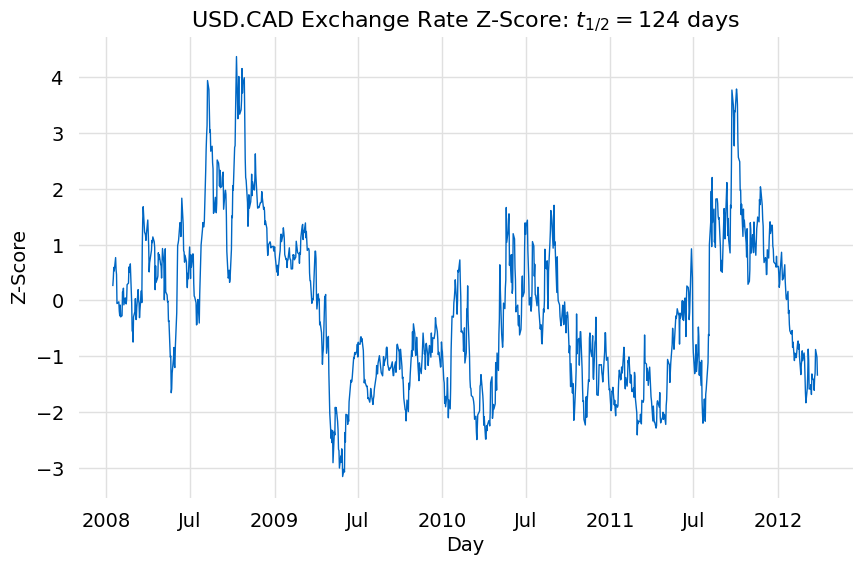

In [42]:
zdate, zscore = stats.compute_zscore(date, usd_cad_close, mean_reversion_half_life)
zscore_plot(zscore, zdate, mean_reversion_half_life)

## Z-Score Indicator Verification

In [44]:
bt_file_path = os.path.abspath('../../../apps/output/mean-reversion-timeseries-CAD=X.csv')
df = read_csv(bt_file_path)
df.fillna(0.0, inplace=True)

In [45]:
df.head()

,Id,CAD=X,len,datetime,open,high,low,close,volume,openinterest,...,cash,value,BuySell,len.4,buy,sell,Trades - Net Profit/Loss,len.5,pnlplus,pnlminus
0,1,CAD=X,1,2007-07-23 23:59:59.999989,1.05,1.05,1.04,1.05,0.0,0.0,...,1000.0,1000.0,BuySell,1,0.0,0.0,Trades - Net Profit/Loss,1,0.0,0.0
1,2,CAD=X,2,2007-07-24 23:59:59.999989,1.05,1.05,1.03,1.04,0.0,0.0,...,1000.0,1000.0,BuySell,2,0.0,0.0,Trades - Net Profit/Loss,2,0.0,0.0
2,3,CAD=X,3,2007-07-25 23:59:59.999989,1.04,1.04,1.03,1.04,0.0,0.0,...,1000.0,1000.0,BuySell,3,0.0,0.0,Trades - Net Profit/Loss,3,0.0,0.0
3,4,CAD=X,4,2007-07-26 23:59:59.999989,1.04,1.06,1.04,1.05,0.0,0.0,...,1000.0,1000.0,BuySell,4,0.0,0.0,Trades - Net Profit/Loss,4,0.0,0.0
4,5,CAD=X,5,2007-07-27 23:59:59.999989,1.05,1.07,1.05,1.06,0.0,0.0,...,1000.0,1000.0,BuySell,5,0.0,0.0,Trades - Net Profit/Loss,5,0.0,0.0


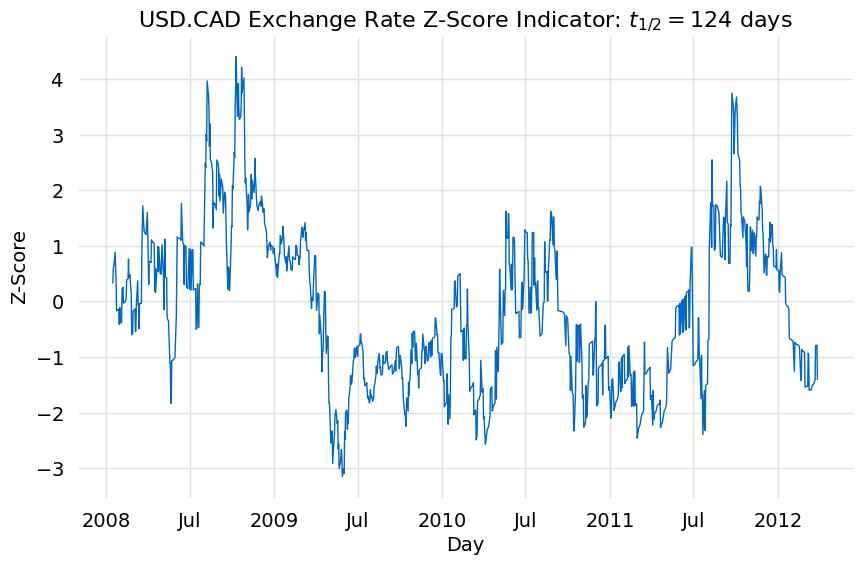

In [77]:
zscore = df.zscore.to_numpy()
zdate = numpy.array([datetime.strptime(item, '%Y-%m-%d %H:%M:%S.%f').date() for item in df.datetime.to_numpy()])
zscore_indicator_plot(zscore[mean_reversion_half_life:], zdate[mean_reversion_half_life:], mean_reversion_half_life)